In [1]:
from pathlib import Path

NOTEBOOK_ROOT = Path().resolve()
DATA_DIR = NOTEBOOK_ROOT / "data"

import pandas as pd
from scipy.spatial.distance import pdist, squareform

from scripts.generalism import (
    GeneralismResult,
    compare_distances,
    compute_generalism,
    do_MDS,
    find_best_axes,
    load_taxon_profile,
    visualize_generalism,
)

In [2]:
# Ensure DATA_DIR exists before loading files
if not DATA_DIR.exists():
    print(f"DATA_DIR not found: {DATA_DIR}")
    print("If the archive is available, unzip data.tar.bz2 in the project root.")
    print("Otherwise set DATA_DIR manually to the folder containing the data files, e.g., DATA_DIR = Path('/path/to/data')")


# Habitat cluster MDS
- This corresponds to STEP 1 of Figure S5

In [3]:
# Load ecological distance between the habitat clusters
ecolocal_distance_matrix = pd.read_csv(DATA_DIR / 'ecological_distance_between_habitat_clusters.tsv', sep='\t', index_col=0, header=0)

# Perform Multidimensional scaling
habitat_cluster_coordinates = do_MDS(ecolocal_distance_matrix)

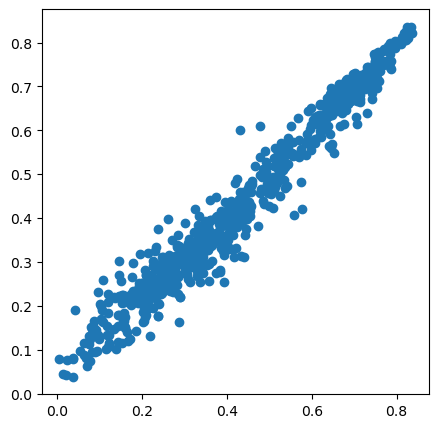

pearson 0.9820953557440663 0.0
spearman 0.9780940569492163 0.0


In [4]:
# Check whether the MDS distance correlates to the original ecological distance
# Figure S5A
stats = compare_distances(squareform(ecolocal_distance_matrix.values), pdist(habitat_cluster_coordinates))
for stat_type, (coef, p) in stats.items():
    print (stat_type, str(coef), str(p)) 

In [5]:
# Optional: this is to find the three axes which correlates the best with the original distance matrix
#best_three_axes, pearson, three_axes_d = find_best_axes(habitat_cluster_coordinates, squareform(ecolocal_distance_dmatrix.values), dim=3)
#best_three_axes = [17, 28, 38]

# Calculate generalism score

In [6]:
# Load the full prevalence table once so multiple taxa can be sampled
TAXON_TABLE = DATA_DIR / 'taxon_prevalence_mean-abundance.tsv'
taxon_prevalence_abundance_df = pd.read_csv(TAXON_TABLE, sep='\t')

In [7]:
# Please use GTDB r207 taxonomy
TARGET_TAXON = 'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Xanthobacteraceae;g__Afipia;s__Afipia sp000497575'
# TARGET_TAXON = 'd__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Propionibacteriales;f__Propionibacteriaceae;g__Cutibacterium;s__Cutibacterium acnes'
# TARGET_TAXON = 'd__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bifidobacterium longum'

PREVALENCE_CUTOFF = 0.01

# Reuse the loaded table to avoid re-reading the TSV for each taxon

target_taxon_df = load_taxon_profile(
    taxon_prevalence_abundance_df,
    TARGET_TAXON,
    PREVALENCE_CUTOFF,
)


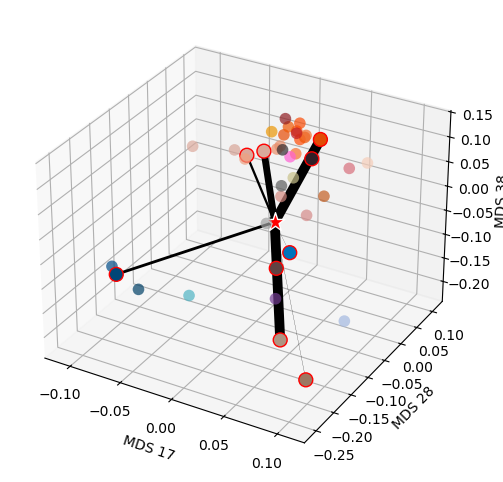

Generalism score: 0.5119
Clusters count: 9


In [8]:
generalism_result = compute_generalism(target_taxon_df, habitat_cluster_coordinates)

visualize_generalism(
    generalism_result,
    target_taxon_df,
    habitat_cluster_coordinates,
)
